## Limpieza y preparación de datos de E-Commerce

Este proyecto tiene como objetivo explorar, limpiar y preparar un conjunto de datos de comercio electrónico para su posterior análisis.

Durante el proceso se revisará la calidad de los datos, incluyendo valores faltantes, registros duplicados, tipos de datos, inconsistencias en los valores de texto, formatos de fechas y otros aspectos que puedan afectar el análisis.

In [208]:
#importamos, cargamos y mostramos datos
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

file_path = "ecommerce_sales_customer_analytics_150k.csv"

ecommerce = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "datascikhan/e-commerce-sales-and-customer-analytics",
    file_path
)

print(ecommerce.head())

C:\Users\COMPUMAX\AppData\Local\Temp\ipykernel_1880\1317531937.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  ecommerce = kagglehub.load_dataset(


     order_id  order_date order_time order_status sales_channel  customer_id  \
0  ORD-301242  2023-11-06   16:37:47    Completed    Mobile App  CUST-003102   
1  ORD-773460  2025-12-24   01:22:36    Completed       Website  CUST-003124   
2  ORD-449374  2021-07-05   14:24:21    Completed    Mobile App  CUST-012496   
3  ORD-567636  2023-01-21   07:20:26    Completed  Social Media  CUST-023928   
4  ORD-820028  2022-05-13   09:46:21    Completed  Social Media  CUST-012730   

    customer_name  customer_age  gender customer_segment  ... discount_amount  \
0    Jasmine Ryan            55    Male         Consumer  ...          477.89   
1     Scott Chase            26    Male          Premium  ...         1456.06   
2    Marc Wheeler            69  Female          Premium  ...           97.30   
3  Jennifer Smith            65    Male         Consumer  ...           53.34   
4    Jessica Wang            34  Female         Consumer  ...          133.63   

  tax_amount shipping_cost net_s

In [209]:
ecommerce.columns

Index(['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel',
       'customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_type', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code', 'payment_method',
       'payment_status', 'currency', 'shipping_method', 'warehouse',
       'delivery_days', 'estimated_delivery_days', 'delivery_status',
       'return_status', 'return_reason', 'customer_rating', 'review_sentiment',
       'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code',
       'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity',
       'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost',
       'net_sales', 'product_cost', 'profit', 'profit_margin_percentage',
       'customer_lifetime_value', 'is_repeat_customer',
       'customer_order_count'],
      dtype='str')

### 1. Exploracion inicial de los datos

Analizaré los datos para entender como esta constituido el dataset, sus columnas y datos.

In [210]:
ecommerce.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [211]:
ecommerce.shape

(138116, 46)

In [212]:
ecommerce.columns

Index(['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel',
       'customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_type', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code', 'payment_method',
       'payment_status', 'currency', 'shipping_method', 'warehouse',
       'delivery_days', 'estimated_delivery_days', 'delivery_status',
       'return_status', 'return_reason', 'customer_rating', 'review_sentiment',
       'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code',
       'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity',
       'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost',
       'net_sales', 'product_cost', 'profit', 'profit_margin_percentage',
       'customer_lifetime_value', 'is_repeat_customer',
       'customer_order_count'],
      dtype='str')

In [213]:
ecommerce.info()

<class 'pandas.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  str    
 1   order_date                138116 non-null  str    
 2   order_time                138116 non-null  str    
 3   order_status              138116 non-null  str    
 4   sales_channel             138116 non-null  str    
 5   customer_id               138116 non-null  str    
 6   customer_name             138116 non-null  str    
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  str    
 9   customer_segment          138116 non-null  str    
 10  customer_type             138116 non-null  str    
 11  customer_city             138116 non-null  str    
 12  customer_state            138116 non-null  str    
 13  customer_country          138116 non-null  str    
 14 

In [214]:
ecommerce.duplicated().sum()

np.int64(0)

## 2. Missing values análisis

Antes de limpiar el dataset, analizaré los valores faltantes en cada columna
para determinar si los valores faltante corresponde a un error o ausencia valida de información.

In [215]:
datos_faltantes = ecommerce.isna().sum()

porcentaje_datos_faltantes = (
    datos_faltantes / len(ecommerce)
    )*100

tabla_faltantes = pd.DataFrame({
    "valores faltantes" : datos_faltantes,
    "porcentaje faltantes" : porcentaje_datos_faltantes
})

tabla_faltantes = tabla_faltantes[
    tabla_faltantes["valores faltantes"] > 0
    ].sort_values(
        by="porcentaje faltantes",
        ascending=False
    )    
tabla_faltantes

,valores faltantes,porcentaje faltantes
return_status,128654,93.149237
return_reason,128654,93.149237
coupon_code,110502,80.006661
campaign_name,83233,60.263112
delivery_days,24557,17.779982
customer_rating,24557,17.779982
estimated_delivery_days,24557,17.779982
customer_review,24557,17.779982
review_sentiment,24557,17.779982


### Entediendo datos faltantes

Analizaré los datos faltantes obtenidos para determinar si constituyen un problema real
de calidad de datos o simplemente son casos donde la informacion no aplica.

In [216]:
ecommerce["return_status"].value_counts(dropna=False)

return_status
NaN         128654
Returned      9462
Name: count, dtype: int64

In [217]:
ecommerce["return_reason"].value_counts(dropna=False)

return_reason
NaN                        128654
Wrong Product                1237
Other                        1208
Changed Mind                 1204
Size Issue                   1182
Defective Product            1174
Late Delivery                1172
Product Not as Expected      1147
Damaged Product              1138
Name: count, dtype: int64

In [218]:
ecommerce[["return_status","return_reason"]].value_counts(dropna=False)

return_status  return_reason          
NaN            NaN                        128654
Returned       Wrong Product                1237
               Other                        1208
               Changed Mind                 1204
               Size Issue                   1182
               Defective Product            1174
               Late Delivery                1172
               Product Not as Expected      1147
               Damaged Product              1138
Name: count, dtype: int64

In [219]:
ecommerce["return_status"] = ecommerce["return_status"].fillna("No reembolsado")
ecommerce["return_reason"] = ecommerce["return_reason"].fillna("No aplica")

ecommerce[["return_status","return_reason"]].value_counts(dropna=False)

return_status   return_reason          
No reembolsado  No aplica                  128654
Returned        Wrong Product                1237
                Other                        1208
                Changed Mind                 1204
                Size Issue                   1182
                Defective Product            1174
                Late Delivery                1172
                Product Not as Expected      1147
                Damaged Product              1138
Name: count, dtype: int64

Al analizar `return_status` y `return_reason`, se observa que los valores faltantes corresponden a registros que no presentan información de devolución. Por esta razón, se reemplazarán los valores faltantes de `return_status` por `"No reembolsado"` y los de `return_reason` por `"No aplica"`. Esto permitirá representar explícitamente la ausencia de información de devolución y facilitar su interpretación en análisis posteriores.

In [220]:
ecommerce["coupon_code"].value_counts(dropna=False).head(15)

coupon_code
NaN       110502
SAVE39       731
SAVE49       727
SAVE40       719
SAVE12       716
SAVE33       715
SAVE26       712
SAVE25       711
SAVE15       709
SAVE36       709
SAVE46       707
SAVE44       704
SAVE21       704
SAVE27       702
SAVE22       702
Name: count, dtype: int64

In [221]:
analisis_cupon = ecommerce.groupby(
    ecommerce["coupon_code"].isna().map({
        True : "Sin cupon",
        False : "Con cupon"
    })
)["discount_amount"].agg(["count","mean","min","max"])

analisis_cupon["porcentaje"] = (
    analisis_cupon["count"]/analisis_cupon["count"].sum()
)*100

analisis_cupon

,count,mean,min,max,porcentaje
coupon_code,,,,,
Con cupon,27614,235.821261,0.0,5046.32,19.993339
Sin cupon,110502,238.071515,0.0,6759.02,80.006661


In [222]:
ecommerce["coupon_code"] = ecommerce["coupon_code"].fillna("No cupon")

ecommerce["coupon_code"].value_counts(dropna=False).head(15)

coupon_code
No cupon    110502
SAVE39         731
SAVE49         727
SAVE40         719
SAVE12         716
SAVE33         715
SAVE26         712
SAVE25         711
SAVE15         709
SAVE36         709
SAVE46         707
SAVE44         704
SAVE21         704
SAVE27         702
SAVE22         702
Name: count, dtype: int64

### Análisis de `coupon_code`

Se identificaron valores faltantes en `coupon_code`. Para determinar si estos registros requerían un tratamiento específico, se comparó `discount_amount` entre los registros con y sin código de cupón.

Los resultados mostraron que aproximadamente el 20% de los registros cuentan con un código de cupón, mientras que el 80% no presenta uno. Además, el valor promedio de `discount_amount` fue similar entre ambos grupos, por lo que no se identificó un comportamiento que justificara un tratamiento diferente para los registros sin código.

Por este motivo, los valores faltantes de `coupon_code` se interpretaron como registros sin cupón y fueron reemplazados por `"No cupon"`. Finalmente, se verificó la distribución de la variable después de la transformación.


In [223]:
ecommerce["campaign_name"].value_counts(dropna=False)

campaign_name
NaN                   83233
Default_Campaign      22989
Google_Search_Q1       2748
Google_Shopping        2746
Google_Display         2731
FB_Retargeting         2270
FB_Dynamic             2233
Friend_Invite          2232
Referral_Program       2198
FB_Prospecting         2161
Insta_Influencer       1822
Insta_Reels            1799
Insta_Stories          1773
Abandoned_Cart         1520
Weekly_Newsletter      1459
Promo_Email            1459
Influencer_Program     1404
Affiliate_Partner      1339
Name: count, dtype: int64

In [224]:
ecommerce.groupby(ecommerce["campaign_name"].isna().map({
    True : "Sin campaña",
    False : "Con campaña"
    }))["marketing_channel"].value_counts()

campaign_name  marketing_channel
Con campaña    Organic Search       11009
               Google Ads            8225
               Direct                8182
               Facebook Ads          6664
               Instagram             5394
               Email Marketing       4438
               Referral              4430
               Affiliate             2743
               TikTok                2201
               YouTube               1597
Sin campaña    Organic Search       16733
               Google Ads           12408
               Direct               12333
               Facebook Ads          9987
               Instagram             8407
               Email Marketing       6780
               Referral              6761
               Affiliate             4105
               TikTok                3236
               YouTube               2483
Name: count, dtype: int64

In [225]:
ecommerce.groupby(
    ecommerce["campaign_name"].isna().map({
        True: "Sin campaña",
        False: "Con campaña"
    })
)["discount_amount"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
campaign_name,,,,
Con campaña,54883,237.539780,0.0,5336.38
Sin campaña,83233,237.675574,0.0,6759.02


In [226]:
ecommerce.groupby(
    ecommerce["campaign_name"].isna().map({
        True: "Sin campaña",
        False: "Con campaña"
    })
)["coupon_code"].value_counts()

campaign_name  coupon_code
Con campaña    No cupon       43755
               SAVE36           306
               SAVE25           303
               SAVE37           298
               SAVE18           296
                              ...  
Sin campaña    SAVE10           384
               SAVE37           383
               SAVE35           382
               SAVE29           369
               SAVE24           364
Name: count, Length: 82, dtype: int64

In [227]:
ecommerce["campaign_name"] = ecommerce["campaign_name"].fillna("Campaña desconocida")

ecommerce["campaign_name"].value_counts(dropna=False)

campaign_name
Campaña desconocida    83233
Default_Campaign       22989
Google_Search_Q1        2748
Google_Shopping         2746
Google_Display          2731
FB_Retargeting          2270
FB_Dynamic              2233
Friend_Invite           2232
Referral_Program        2198
FB_Prospecting          2161
Insta_Influencer        1822
Insta_Reels             1799
Insta_Stories           1773
Abandoned_Cart          1520
Weekly_Newsletter       1459
Promo_Email             1459
Influencer_Program      1404
Affiliate_Partner       1339
Name: count, dtype: int64

Se analizaron los valores faltantes de `campaign_name` comparándolos con `marketing_channel` y `coupon_code`. Los registros sin nombre de campaña aparecen asociados a diferentes canales de marketing y, además, algunos de estos registros presentan códigos de cupón. Esto indica que la ausencia de `campaign_name` no necesariamente representa la ausencia de una campaña, por lo que no existe evidencia suficiente para reemplazar los valores faltantes por `"Sin campaña"`. En consecuencia, se utilizó `"Campaña desconocida"` para representar explícitamente que no se dispone del nombre de la campaña.


In [228]:
ecommerce["delivery_days"].isna().sum()

np.int64(24557)

In [229]:
ecommerce.loc[ecommerce["delivery_days"].isna(),["order_status","delivery_status"]].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

Análisis datos faltantes`delivery_days`

In [230]:
ecommerce["customer_rating"].isna().sum()

np.int64(24557)

In [231]:
ecommerce.loc[ecommerce["customer_rating"].isna(),["order_status","delivery_status"]].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

Análisis datos faltantes`customer_rating`

In [232]:
ecommerce["estimated_delivery_days"].isna().sum()

np.int64(24557)

In [233]:
ecommerce.loc[ecommerce["estimated_delivery_days"].isna(),["order_status","delivery_status"]].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

Análisis datos faltantes`estimated_delivery_days`

In [234]:
ecommerce["customer_review"].isna().sum()

np.int64(24557)

In [235]:
ecommerce.loc[ecommerce["customer_review"].isna(),["order_status","delivery_status"]].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

Análisis datos faltantes`customer_review`

In [236]:
ecommerce["review_sentiment"].isna().sum()

np.int64(24557)

In [237]:
ecommerce.loc[ecommerce["review_sentiment"].isna(),["order_status","delivery_status"]].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

Analisis datos faltantes`review_sentiment`

Se identificaron valores faltantes en `delivery_days`, `customer_rating`, `estimated_delivery_days`, `customer_review` y `review_sentiment`, todos correspondientes a los mismos 24.557 registros (17,78 % del dataset). Al analizar estos registros, se comprobó que corresponden a pedidos cuyo `delivery_status` es `"Cancelled"`. Por este motivo, los valores faltantes representan información que no resulta aplicable para estos pedidos, por lo que se conservaron como `NaN` en lugar de asignar valores artificiales.


### Resumen del análisis y tratamiento de valores faltantes

Se analizaron los valores faltantes de forma individual, considerando el contexto y la relación entre las variables antes de aplicar cualquier transformación. Los faltantes de `return_status`, `return_reason`, `coupon_code` y `campaign_name` fueron tratados según su significado, mientras que los de `delivery_days`, `customer_rating`, `estimated_delivery_days`, `customer_review` y `review_sentiment` se conservaron como `NaN` al corresponder a pedidos con `delivery_status = "Cancelled"`.

El objetivo fue tratar únicamente los faltantes que podían interpretarse de forma justificada, conservando aquellos que representan una ausencia válida de información.


## 3. Análisis y validación de calidad de los datos

In [238]:
ecommerce.dtypes

order_id                        str
order_date                      str
order_time                      str
order_status                    str
sales_channel                   str
customer_id                     str
customer_name                   str
customer_age                  int64
gender                          str
customer_segment                str
customer_type                   str
customer_city                   str
customer_state                  str
customer_country                str
region                          str
customer_postal_code          int64
payment_method                  str
payment_status                  str
currency                        str
shipping_method                 str
warehouse                       str
delivery_days               float64
estimated_delivery_days     float64
delivery_status                 str
return_status                   str
return_reason                   str
customer_rating             float64
review_sentiment            

In [239]:
ecommerce[["order_date","order_time"]].head()

,order_date,order_time
0,2023-11-06,16:37:47
1,2025-12-24,01:22:36
2,2021-07-05,14:24:21
3,2023-01-21,07:20:26
4,2022-05-13,09:46:21


In [240]:
ecommerce["order_date"] = pd.to_datetime(
    ecommerce["order_date"],
    format="%Y-%m-%d"
    )

ecommerce["order_date"].head()

0   2023-11-06
1   2025-12-24
2   2021-07-05
3   2023-01-21
4   2022-05-13
Name: order_date, dtype: datetime64[us]

In [241]:
ecommerce['order_time'] = pd.to_datetime(
    ecommerce['order_time'],
    format='%H:%M:%S'
).dt.time

ecommerce["order_time"].head()

0    16:37:47
1    01:22:36
2    14:24:21
3    07:20:26
4    09:46:21
Name: order_time, dtype: object

Se observó que las columnas `order_date` y `order_time` se encontraban almacenadas como cadenas de texto (`str`). Se transformaron a tipos de fecha y hora, respectivamente, con el objetivo de facilitar su manipulación y permitir realizar análisis temporales posteriormente, en caso de ser necesario.

In [242]:
ecommerce.select_dtypes(include="str").nunique().sort_values()

return_status             2
customer_type             3
review_sentiment          3
gender                    3
customer_segment          4
shipping_method           4
order_status              4
sales_channel             4
payment_status            4
delivery_status           4
region                    5
payment_method            7
customer_country          7
currency                  7
return_reason             9
marketing_channel        10
campaign_name            18
warehouse                19
customer_review          25
customer_state           38
coupon_code              41
customer_city         15516
customer_name         21564
customer_id           24911
order_id             138116
dtype: int64

In [243]:
columnas_categoricas = [
    "return_status",
    "customer_type",
    "review_sentiment",
    "gender",
    "customer_segment",
    "shipping_method",
    "order_status",
    "sales_channel",
    "payment_status",
    "delivery_status",
    "region",
    "payment_method"
]

ecommerce[columnas_categoricas].head(10)

,return_status,customer_type,review_sentiment,gender,customer_segment,shipping_method,order_status,sales_channel,payment_status,delivery_status,region,payment_method
0,No reembolsado,Loyal,Positive,Male,Consumer,Standard,Completed,Mobile App,Paid,On Time,South,Digital Wallet
1,No reembolsado,Loyal,Positive,Male,Premium,Economy,Completed,Website,Pending,On Time,South,Debit Card
2,No reembolsado,Loyal,Positive,Female,Premium,Express,Completed,Mobile App,Paid,On Time,East,Cash on Delivery
3,No reembolsado,Loyal,Positive,Male,Consumer,Express,Completed,Social Media,Paid,On Time,South,Debit Card
4,No reembolsado,Loyal,Neutral,Female,Consumer,Standard,Completed,Social Media,Paid,Delayed,West,Digital Wallet
5,No reembolsado,Returning,NaN,Female,Consumer,Standard,Pending,Website,Paid,Cancelled,Central,Credit Card
6,No reembolsado,Loyal,Neutral,Female,Consumer,Economy,Completed,Mobile App,Paid,Delayed,South,Credit Card
7,No reembolsado,Loyal,Positive,Female,VIP,Standard,Completed,Mobile App,Paid,On Time,East,PayPal
8,No reembolsado,Loyal,Neutral,Female,Consumer,Same Day,Completed,Mobile App,Paid,On Time,East,Credit Card
9,No reembolsado,Loyal,Positive,Female,Consumer,Standard,Completed,Mobile App,Paid,On Time,East,Credit Card


In [244]:
ecommerce[columnas_categoricas] = ecommerce[columnas_categoricas].astype("category")

ecommerce[columnas_categoricas].dtypes

return_status       category
customer_type       category
review_sentiment    category
gender              category
customer_segment    category
shipping_method     category
order_status        category
sales_channel       category
payment_status      category
delivery_status     category
region              category
payment_method      category
dtype: object

Se transformaron las variables categóricas al tipo `category` para facilitar su gestión y optimizar su representación dentro del DataFrame.

## Definición de preguntas de negocio

### Definición de preguntas de negocio

### 1. Marketing, campañas y cupones

- ¿Qué campaña genera mayores ventas?
- ¿Qué campaña tiene mayor `profit`?
- ¿Qué `marketing_channel` concentra más ventas?

### 2. Comportamiento de los clientes

- ¿Qué tipo de clientes realiza más pedidos?
- ¿Qué tipo de clientes genera mayor gasto?
- ¿Qué tipo de clientes genera mayor `profit`?

### 3. Distribución geográfica

- ¿En qué ciudades se concentra el mayor volumen de ventas?
- ¿Qué ciudades generan mayor `profit`?
- ¿Las ciudades con mayor volumen de ventas son también las más rentables?

### 4. Evolución temporal

- ¿Cómo han evolucionado las ventas a lo largo del tiempo?
- ¿Qué año presenta el mayor volumen de ventas?
- ¿Qué meses concentran el mayor volumen de ventas?
- ¿Qué días de la semana concentran más pedidos?
- ¿En qué horas se concentra el mayor número de pedidos?

### 5. Envíos, devoluciones y satisfacción

- ¿Existe alguna relación entre el método de envío y las devoluciones?
- ¿Existen diferencias en la satisfacción de los clientes según el método de envío?
- ¿Qué métodos de envío presentan mayor cantidad de devoluciones?
- ¿Qué métodos de envío presentan menores niveles de satisfacción?

## Transformación de datos

In [245]:
ecommerce["order_year"] = ecommerce["order_date"].dt.year

ecommerce["order_month"] = ecommerce["order_date"].dt.month

ecommerce["order_weekday"] = ecommerce["order_date"].dt.day_name()

ecommerce["order_hour"] = ecommerce["order_time"].apply(lambda x: x.hour)

Se crearon nuevas columnas (`order_hour`, `order_month`, `order_weekday` y `order_year`) para facilitar el análisis y dar respuesta a las preguntas de negocio relacionadas con la evolución temporal de las ventas y los pedidos.


In [246]:
import matplotlib.pyplot as plt
import seaborn as sns

## Analisis de negocio

### 1. Marketing, campañas y cupones

> - ¿Qué campaña genera mayores ventas?

In [247]:
#campaña que genera mas ventas
analisis_campañas = (
    ecommerce[ecommerce["campaign_name"] != "Campaña desconocida"]
    .groupby(["currency","campaign_name"])
    .agg(
        pedidos=("order_id", "count"),
        ventas_totales=("net_sales", "sum"),
        ventas_promedio=("net_sales", "mean")
    )
    .sort_values("ventas_totales", ascending=False)
)

mayor_ventas_campañas = (
    analisis_campañas
    .groupby(level="currency")
    .head(1)
)

mayor_ventas_campañas

,,pedidos,ventas_totales,ventas_promedio
currency,campaign_name,,,
USD,Default_Campaign,13745,16767292.89,1219.883077
GBP,Default_Campaign,3344,4625510.72,1383.226890
EUR,Default_Campaign,1979,2783598.64,1406.568287
CAD,Default_Campaign,1141,1489981.48,1305.855811
AUD,Default_Campaign,1116,1484310.17,1330.027034
INR,Default_Campaign,969,1340339.58,1383.219381
AED,Default_Campaign,695,878837.26,1264.514043


Debido a que el dataset contiene diferentes monedas, las ventas se analizaron por moneda para evitar realizar comparaciones directas entre valores monetarios que no son equivalentes. Para cada moneda se identificó la campaña con el mayor volumen de ventas totales.

`Default_Campaign` registra el mayor volumen de ventas dentro de cada una de las monedas presentes en el dataset."

> - ¿Qué campaña tiene mayor `profit`?

In [248]:

# Campaña que genera más profit

analisis_campañas_profit = (
    ecommerce[ecommerce["campaign_name"] != "Campaña desconocida"]
    .groupby(["currency", "campaign_name"])
    .agg(
        pedidos=("order_id", "count"),
        ventas_totales=("net_sales", "sum"),
        profit_total=("profit", "sum")
    )
    .sort_values(
        ["currency", "profit_total"],
        ascending=[True, False]
    )
)
#se imprime el mayor de cada moneda
mayor_profit_moneda = (
    analisis_campañas_profit
    .groupby(level="currency")
    .head(1)
)

mayor_profit_moneda

,,pedidos,ventas_totales,profit_total
currency,campaign_name,,,
AED,Default_Campaign,695,878837.26,345554.59
AUD,Default_Campaign,1116,1484310.17,617114.37
CAD,Default_Campaign,1141,1489981.48,643371.87
EUR,Default_Campaign,1979,2783598.64,1321978.85
GBP,Default_Campaign,3344,4625510.72,2199591.14
INR,Default_Campaign,969,1340339.58,633864.59
USD,Default_Campaign,13745,16767292.89,6900480.58


`Default_Campaign` registra el mayor profit dentro de cada una de las monedas presentes en el dataset.

> - ¿Qué `marketing_channel` concentra más ventas?

In [249]:
#marketing chanel concentra mas ventas
analisis_marketing = (
    ecommerce
    .groupby(["currency", "marketing_channel"])
    .agg(
        pedidos=("order_id", "count"),
        ventas_totales=("net_sales", "sum"),
        promedio_ventas=("net_sales", "mean")
    )
    .sort_values("ventas_totales", ascending=False)
)
#se imprime el mayor de cada moneda
mayor_ventas_marketing = (
    analisis_marketing
    .groupby(level="currency")
    .head(1)
)

mayor_ventas_marketing

,,pedidos,ventas_totales,promedio_ventas
currency,marketing_channel,,,
USD,Organic Search,16517,20394392.75,1234.751635
GBP,Organic Search,4044,5657728.42,1399.042636
EUR,Organic Search,2293,3193318.08,1392.637628
CAD,Organic Search,1422,1833351.01,1289.276378
AUD,Organic Search,1369,1807270.44,1320.139109
INR,Organic Search,1184,1606069.25,1356.477407
AED,Organic Search,913,1166079.51,1277.195520


`Organic Search` registra el mayor volumen de ventas dentro de cada una de las monedas presentes en el dataset.

también registra el mayor número de pedidos dentro de cada moneda.

### 2. Comportamiento de los clientes

>- ¿Qué tipo de clientes realiza más pedidos?

In [250]:
analisis_cliente_pedido = (
    ecommerce.groupby("customer_id")
    .agg(
       nombre =("customer_name", "first"),
       total_pedidos = ("order_id", "count")
    )
    .sort_values("total_pedidos",ascending=False)
)

top_10_clientes = analisis_cliente_pedido.head(10)
top_10_clientes

,nombre,total_pedidos
customer_id,,
CUST-014687,Amy Camacho,19
CUST-020052,Justin Rodriguez,17
CUST-020091,Jason Williams,17
CUST-003453,Michael Burns,17
CUST-012813,Ashley Taylor,17
CUST-022441,Heather Jones,16
CUST-002969,Tracy Mendez,16
CUST-019647,Michael White,15
CUST-019094,David Barnes,15


`Amy Camacho` es el cliente que registra la mayor cantidad de pedidos, con un total de `19`

>- ¿Qué tipo de clientes genera mayor gasto?

In [251]:
analisis_cliente_gastos = (
    ecommerce.groupby(["currency","customer_id"])
    .agg(
       nombre =("customer_name", "first"),
       total_pedidos = ("order_id", "count"),
       total_ventas = ("net_sales","sum")
    )
    .sort_values("total_pedidos",ascending=False)
)
#se imprime el mayor de cada moneda
mayor_ventas_cliente = (
    analisis_cliente_gastos
    .groupby(level="currency")
    .head(1)
)
mayor_ventas_cliente

,,nombre,total_pedidos,total_ventas
currency,customer_id,,,
USD,CUST-014687,Amy Camacho,19,21203.24
INR,CUST-012813,Ashley Taylor,17,23706.02
GBP,CUST-020091,Jason Williams,17,23770.34
CAD,CUST-012814,Robert Brown,15,17964.83
AUD,CUST-019094,David Barnes,15,18988.81
EUR,CUST-005902,Justin Caldwell,14,21968.16
AED,CUST-008799,Joseph Smith,13,24444.72


>- ¿Qué tipo de clientes genera mayor `profit`?

In [252]:
analisis_cliente_profit = (
    ecommerce.groupby(["currency","customer_id"])
    .agg(
       nombre =("customer_name", "first"),
       total_pedidos = ("order_id", "count"),
       total_ventas = ("net_sales","sum"),
       total_profit = ("profit","sum")
    )
    .sort_values("total_pedidos",ascending=False)
)
#se imprime el mayor de cada moneda
mayor_profit_cliente = (
    analisis_cliente_profit
    .groupby(level="currency")
    .head(1)
)
mayor_profit_cliente

,,nombre,total_pedidos,total_ventas,total_profit
currency,customer_id,,,,
USD,CUST-014687,Amy Camacho,19,21203.24,9692.69
INR,CUST-012813,Ashley Taylor,17,23706.02,11491.01
GBP,CUST-020091,Jason Williams,17,23770.34,11485.11
CAD,CUST-012814,Robert Brown,15,17964.83,8206.99
AUD,CUST-019094,David Barnes,15,18988.81,7126.04
EUR,CUST-005902,Justin Caldwell,14,21968.16,11374.84
AED,CUST-008799,Joseph Smith,13,24444.72,7978.19


Debido a que el dataset contiene diferentes monedas, se identificaron los clientes con mayor volumen de ventas y `profit` dentro de cada moneda. De esta forma, se evita comparar directamente valores monetarios expresados en diferentes monedas.

> **Nota:** Para realizar una comparación global entre clientes, sería necesario convertir los valores a una moneda común mediante tasas de cambio.


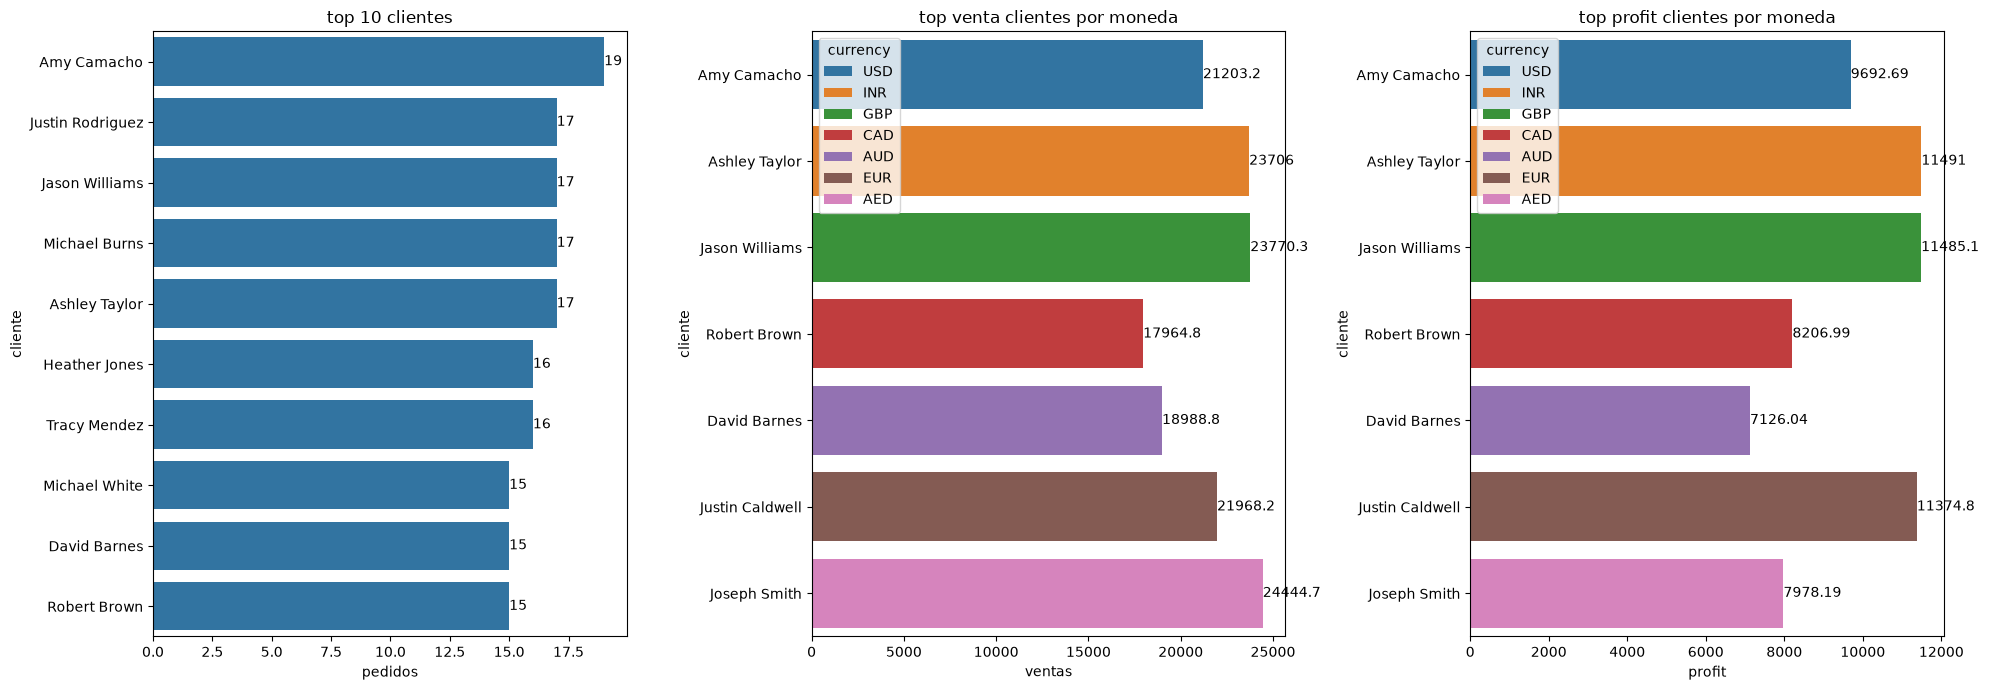

In [253]:
fig, axes = plt.subplots(1, 3, figsize=(20,7))
#Grafico 1
sns.barplot(
    data=top_10_clientes,
    x="total_pedidos",
    y="nombre",
    ax=axes[0]
)
axes[0].set_title("top 10 clientes")
axes[0].set_xlabel("pedidos")
axes[0].set_ylabel("cliente")
axes[0].bar_label(axes[0].containers[0])

#Grafico 2
datos_grafico2 = mayor_ventas_cliente.reset_index()
sns.barplot(
    data=datos_grafico2,
    x="total_ventas",
    y="nombre",
    hue = "currency",
    ax=axes[1]
)
axes[1].set_title("top venta clientes por moneda")
axes[1].set_xlabel("ventas")
axes[1].set_ylabel("cliente")
for container in axes[1].containers:
    axes[1].bar_label(container)
    
#Grafico 3
datos_grafico3 = mayor_profit_cliente.reset_index()
sns.barplot(
    data=datos_grafico3,
    x="total_profit",
    y="nombre",
    hue = "currency",
    ax=axes[2]
)
axes[2].set_title("top profit clientes por moneda")
axes[2].set_xlabel("profit")
axes[2].set_ylabel("cliente")
for container in axes[2].containers:
    axes[2].bar_label(container)
    
plt.tight_layout()
plt.show()

### 3. Distribución geográfica

>- ¿En qué ciudades se concentra el mayor volumen de ventas?

In [254]:
analisis_ciudad_ventas = (
    ecommerce.groupby(["currency","customer_city"])
    .agg(
        total_pedidos = ("order_id", "count"),
        total_ventas = ("net_sales", "sum")
    )
    .sort_values("total_ventas", ascending = False)
)
#se imprime el mayor de cada moneda
mayor_venta_ciudad = (
    analisis_ciudad_ventas
    .groupby(level="currency")
    .head(1)
)
mayor_venta_ciudad

,,total_pedidos,total_ventas
currency,customer_city,,
USD,South James,81,95997.01
GBP,South Michael,43,54887.80
EUR,Port Michael,27,42740.37
AED,Lake Charles,25,31286.18
AUD,South Christopher,17,30994.47
CAD,Mayside,15,30268.44
INR,Jonesmouth,16,30061.58


>- ¿Qué ciudades generan mayor `profit`?

In [255]:
analisis_ciudad_profit = (
    ecommerce.groupby(["currency","customer_city"])
    .agg(
        total_profit = ("profit","sum")
    )
    .sort_values("total_profit",ascending = False)
)
#se imprime el mayor de cada moneda
mayor_profit_ciudad = (
    analisis_ciudad_profit
    .groupby(level = "currency")
    .head(1)
)

mayor_profit_ciudad

,,total_profit
currency,customer_city,
USD,South Michael,42173.36
GBP,South Michael,26576.82
EUR,Port Michael,20801.75
AUD,South Christopher,13454.69
INR,Smithmouth,12394.51
CAD,Mayside,11818.95
AED,Lake Charles,10140.32


Debido a que el dataset contiene diferentes monedas, se identificó la ciudad con mayor volumen de ventas y mayor profit dentro de cada moneda. De esta forma, se evita comparar directamente valores monetarios expresados en diferentes monedas.

>- ¿Las ciudades con mayor volumen de ventas son también las más rentables?

In [256]:
comparacion_ciudades = analisis_ciudad_ventas.join(
    analisis_ciudad_profit["total_profit"]
)

comparacion_ciudades["rentabilidad"] = (
    comparacion_ciudades["total_profit"]
    / comparacion_ciudades["total_ventas"]
    * 100
)
#se imprime el mayor de cada moneda
mayor_rentabilidad_ciudad = (
    comparacion_ciudades
    .sort_values("rentabilidad", ascending=False)
    .groupby(level="currency")
    .head(1)
)

mayor_rentabilidad_ciudad

,,total_pedidos,total_ventas,total_profit,rentabilidad
currency,customer_city,,,,
GBP,Schmidtfurt,3,803.43,564.28,70.233872
USD,New Christine,1,1036.99,715.91,69.037310
EUR,Marcusstad,4,3520.17,2372.41,67.394757
AUD,Garyfort,3,1480.49,965.57,65.219623
INR,Kellerfort,2,1669.30,1063.06,63.682981
CAD,West Sarahborough,1,663.67,417.92,62.971055
AED,North Francisco,1,968.57,566.72,58.511001


Las ciudades con mayor volumen de ventas no coinciden con las ciudades que presentan mayor rentabilidad dentro de ninguna de las monedas analizadas. Esto muestra que un mayor volumen de ventas no implica necesariamente un mayor porcentaje de rentabilidad.

Además, las ciudades con mayor rentabilidad presentan volúmenes de ventas considerablemente menores, por lo que el porcentaje de rentabilidad debe analizarse junto con el volumen de ventas y el `profit` generado.


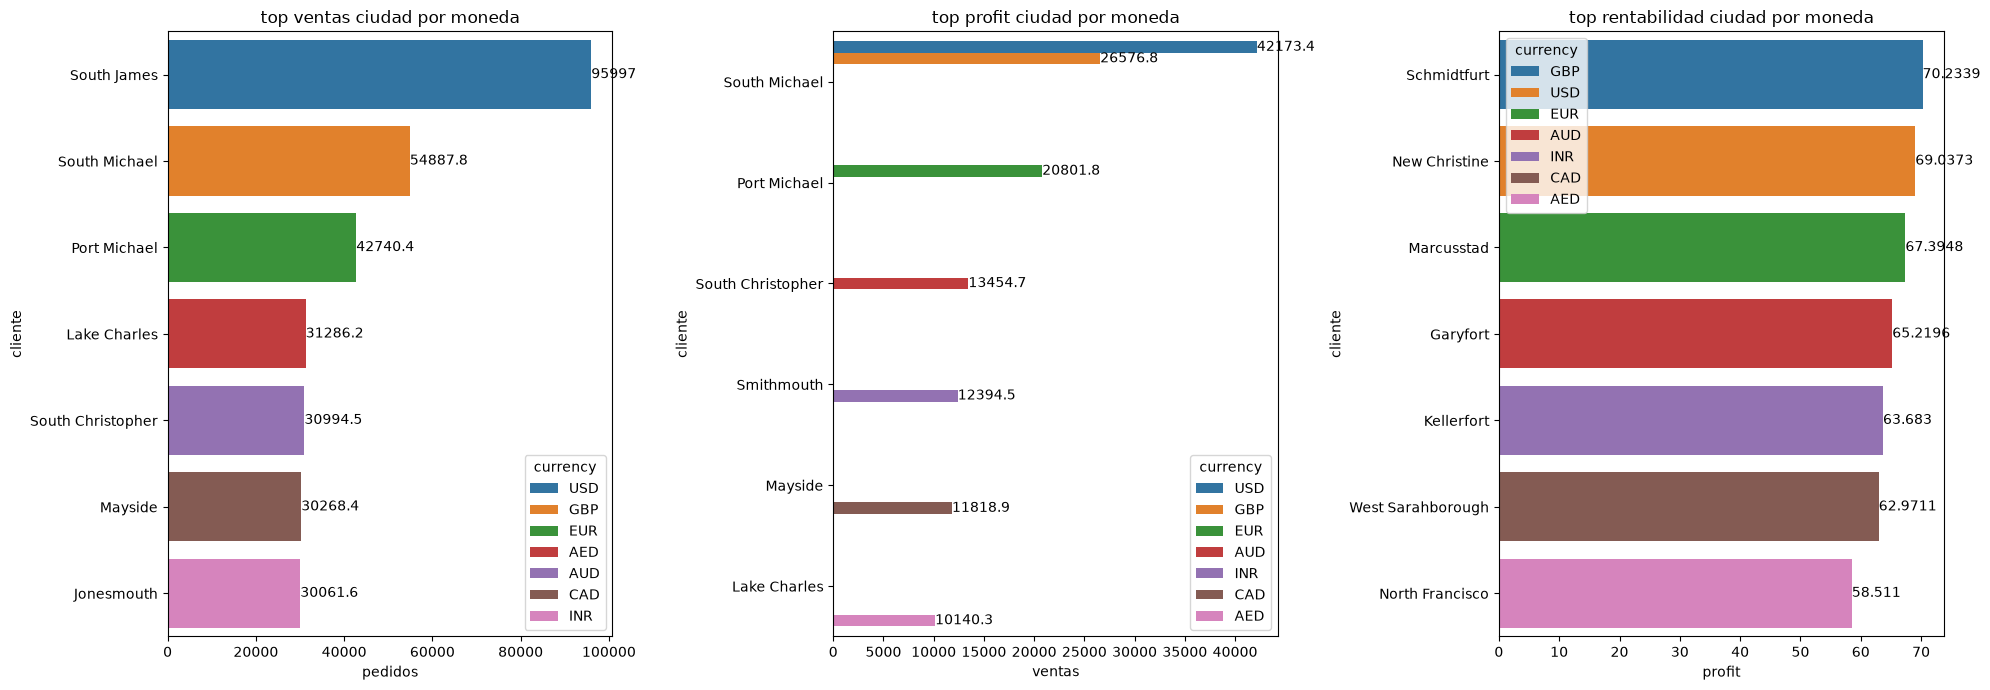

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20,7))
#Grafico 1
datos_grafico1 = mayor_venta_ciudad.reset_index()
sns.barplot(
    data=datos_grafico1,
    x="total_ventas",
    y="customer_city",
    hue = "currency",
    ax=axes[0]
)
axes[0].set_title("top ventas ciudad por moneda")
axes[0].set_xlabel("pedidos")
axes[0].set_ylabel("cliente")
for container in axes[0].containers:
    axes[0].bar_label(container)

#Grafico 2
datos_grafico2 = mayor_profit_ciudad.reset_index()
sns.barplot(
    data=datos_grafico2,
    x="total_profit",
    y="customer_city",
    hue = "currency",
    ax=axes[1]
)
axes[1].set_title("top profit ciudad por moneda")
axes[1].set_xlabel("ventas")
axes[1].set_ylabel("cliente")
for container in axes[1].containers:
    axes[1].bar_label(container)
    
#Grafico 3
datos_grafico3 = mayor_rentabilidad_ciudad.reset_index()
sns.barplot(
    data=datos_grafico3,
    x="rentabilidad",
    y="customer_city",
    hue = "currency",
    ax=axes[2]
)
axes[2].set_title("top rentabilidad ciudad por moneda")
axes[2].set_xlabel("profit")
axes[2].set_ylabel("cliente")
for container in axes[2].containers:
    axes[2].bar_label(container)
    
plt.tight_layout()
plt.show()

### 4. Evolución temporal

- ¿Cómo han evolucionado las ventas a lo largo del tiempo?

In [258]:
evolucion_anual = (
    ecommerce
    .groupby(["currency", "order_year"])
    .agg(
        total_pedidos=("order_id", "count"),
        total_ventas=("net_sales", "sum")
    )
    .sort_index()
)

evolucion_anual

total_pedidos  total_ventas
currency order_year                             
AED      2021                  836    1011491.57
         2022                  811    1037029.49
         2023                  854    1066771.60
         2024                  812     972009.06
         2025                  859    1078671.69
AUD      2021                 1380    1897079.50
         2022                 1347    1711554.83
         2023                 1332    1683237.00
         2024                 1396    1786232.71
         2025                 1339    1735586.47
CAD      2021                 1420    1950961.68
         2022                 1360    1800162.81
         2023                 1413    1900556.89
         2024                 1443    1762625.79
         2025                 1379    1784541.31
EUR      2021                 2379    3349075.97
         2022                 2378    3271733.40
         2023                 2292    3107692.05
         2024                 2269    3191020.37
         2025                 2275    3124650.12
GBP      2021                 3953    5582896.14
         2022                 4045    5596476.23
         2023                 4058    5582070.63
         2024                 4101    5620645.98
         2025                 4078    5581111.81
INR      2021                 1110    1458335.60
         2022                 1179    1590190.46
         2023                 1084    1534078.18
         2024                 1218    1607730.79
         2025                 1116    1527952.25
USD      2021                16476   20472810.21
         2022                16444   20320735.40
         2023                16599   20653737.39
         2024                16529   20526187.58
         2025                16552   20256620.78

Al analizar las ventas y el número de pedidos por año y moneda, se observa que ambos indicadores se mantienen relativamente estables entre 2021 y 2025. Las variaciones anuales son moderadas y no se identifica una tendencia sostenida de crecimiento o disminución.

Por lo tanto, durante el periodo analizado, el volumen de ventas y pedidos presenta un comportamiento estable.

>- ¿Qué año presenta el mayor volumen de ventas?

In [259]:
mayor_venta_año = (
    ecommerce
    .groupby(["currency","order_year"])
    .agg(
        total_venta = ("net_sales", "sum")
    )
    .sort_values("total_venta",ascending = False)
)
#se imprime el mayor de cada moneda
año_mayor_venta = (
    mayor_venta_año
    .groupby(level = "currency")
    .head(1)
)

año_mayor_venta

,,total_venta
currency,order_year,
USD,2023,20653737.39
GBP,2024,5620645.98
EUR,2021,3349075.97
CAD,2021,1950961.68
AUD,2021,1897079.50
INR,2024,1607730.79
AED,2025,1078671.69


El año con mayor volumen de ventas varía según la moneda analizada. USD alcanza su máximo en 2023, GBP e INR en 2024, EUR, CAD y AUD en 2021, mientras que AED presenta su máximo en 2025.

Esto refuerza el comportamiento estable observado en la evolución anual, ya que no se identifica un único año que concentre el mayor volumen de ventas en todas las monedas.

>- ¿Qué meses concentran el mayor volumen de ventas?

In [260]:
mayor_venta_mes = (
    ecommerce
    .groupby(["currency","order_month"])
    .agg(
        año = ("order_year", "first"),
        total_venta = ("net_sales", "sum")
    )
    .sort_values("total_venta",ascending = False)
)
#se imprime el mayor de cada moneda
mes_mayor_venta = (
    mayor_venta_mes
    .groupby(level = "currency")
    .head(1)
)

mes_mayor_venta


,,año,total_venta
currency,order_month,,
USD,12,2024,13589601.34
GBP,12,2024,3510513.67
EUR,12,2025,2130430.78
CAD,11,2025,1247481.61
AUD,12,2022,1173752.48
INR,12,2023,1029062.47
AED,12,2024,653061.16


El mayor volumen de ventas mensual se concentra principalmente en diciembre. Este mes registra el máximo histórico de ventas en cinco de las siete monedas analizadas, mientras que CAD alcanza su máximo en noviembre.

Los años en los que se presentan estos máximos varían según la moneda, por lo que el comportamiento debe analizarse de forma independiente para cada una.

>- ¿Qué días de la semana concentran más pedidos?

In [261]:
maxpedido_dia_semana = (
    ecommerce
    .groupby("order_weekday")
    .agg(
        total_pedidos =("order_id","count")
    )
    .sort_values("total_pedidos",ascending = False)
)

maxpedido_dia_semana

,total_pedidos
order_weekday,
Saturday,19950
Monday,19790
Tuesday,19775
Thursday,19755
Wednesday,19729
Friday,19637
Sunday,19480


El sábado registra el mayor número de pedidos con 19.950, mientras que el domingo presenta la menor cantidad con 19.480. Sin embargo, las diferencias entre los días son relativamente pequeñas, por lo que la distribución de pedidos se mantiene bastante equilibrada a lo largo de la semana.

>- ¿En qué horas se concentra el mayor número de pedidos?

In [262]:
max_pedido_hora = (
    ecommerce
    .groupby("order_hour")
    .agg(
        total_pedidos = ("order_id","count")
    )
    .sort_values("total_pedidos", ascending = False)
)

max_pedido_hora["porcentaje_pedidos"] = (
    max_pedido_hora["total_pedidos"]
    / max_pedido_hora["total_pedidos"].sum()
    * 100
)

max_pedido_hora

,total_pedidos,porcentaje_pedidos
order_hour,,
8,5883,4.259463
2,5865,4.246431
4,5851,4.236294
21,5813,4.208781
12,5803,4.201541
23,5799,4.198645
3,5791,4.192852
10,5778,4.183440
13,5777,4.182716


Los pedidos presentan una distribución bastante uniforme durante las 24 horas del día. La hora con mayor cantidad de pedidos es las 08:00, con 5.883 pedidos (4,26 %), mientras que las 18:00 registra la menor cantidad, con 5.662 pedidos (4,10 %).

La diferencia entre ambas horas es reducida, por lo que no se observa una concentración significativa de pedidos en una hora específica.

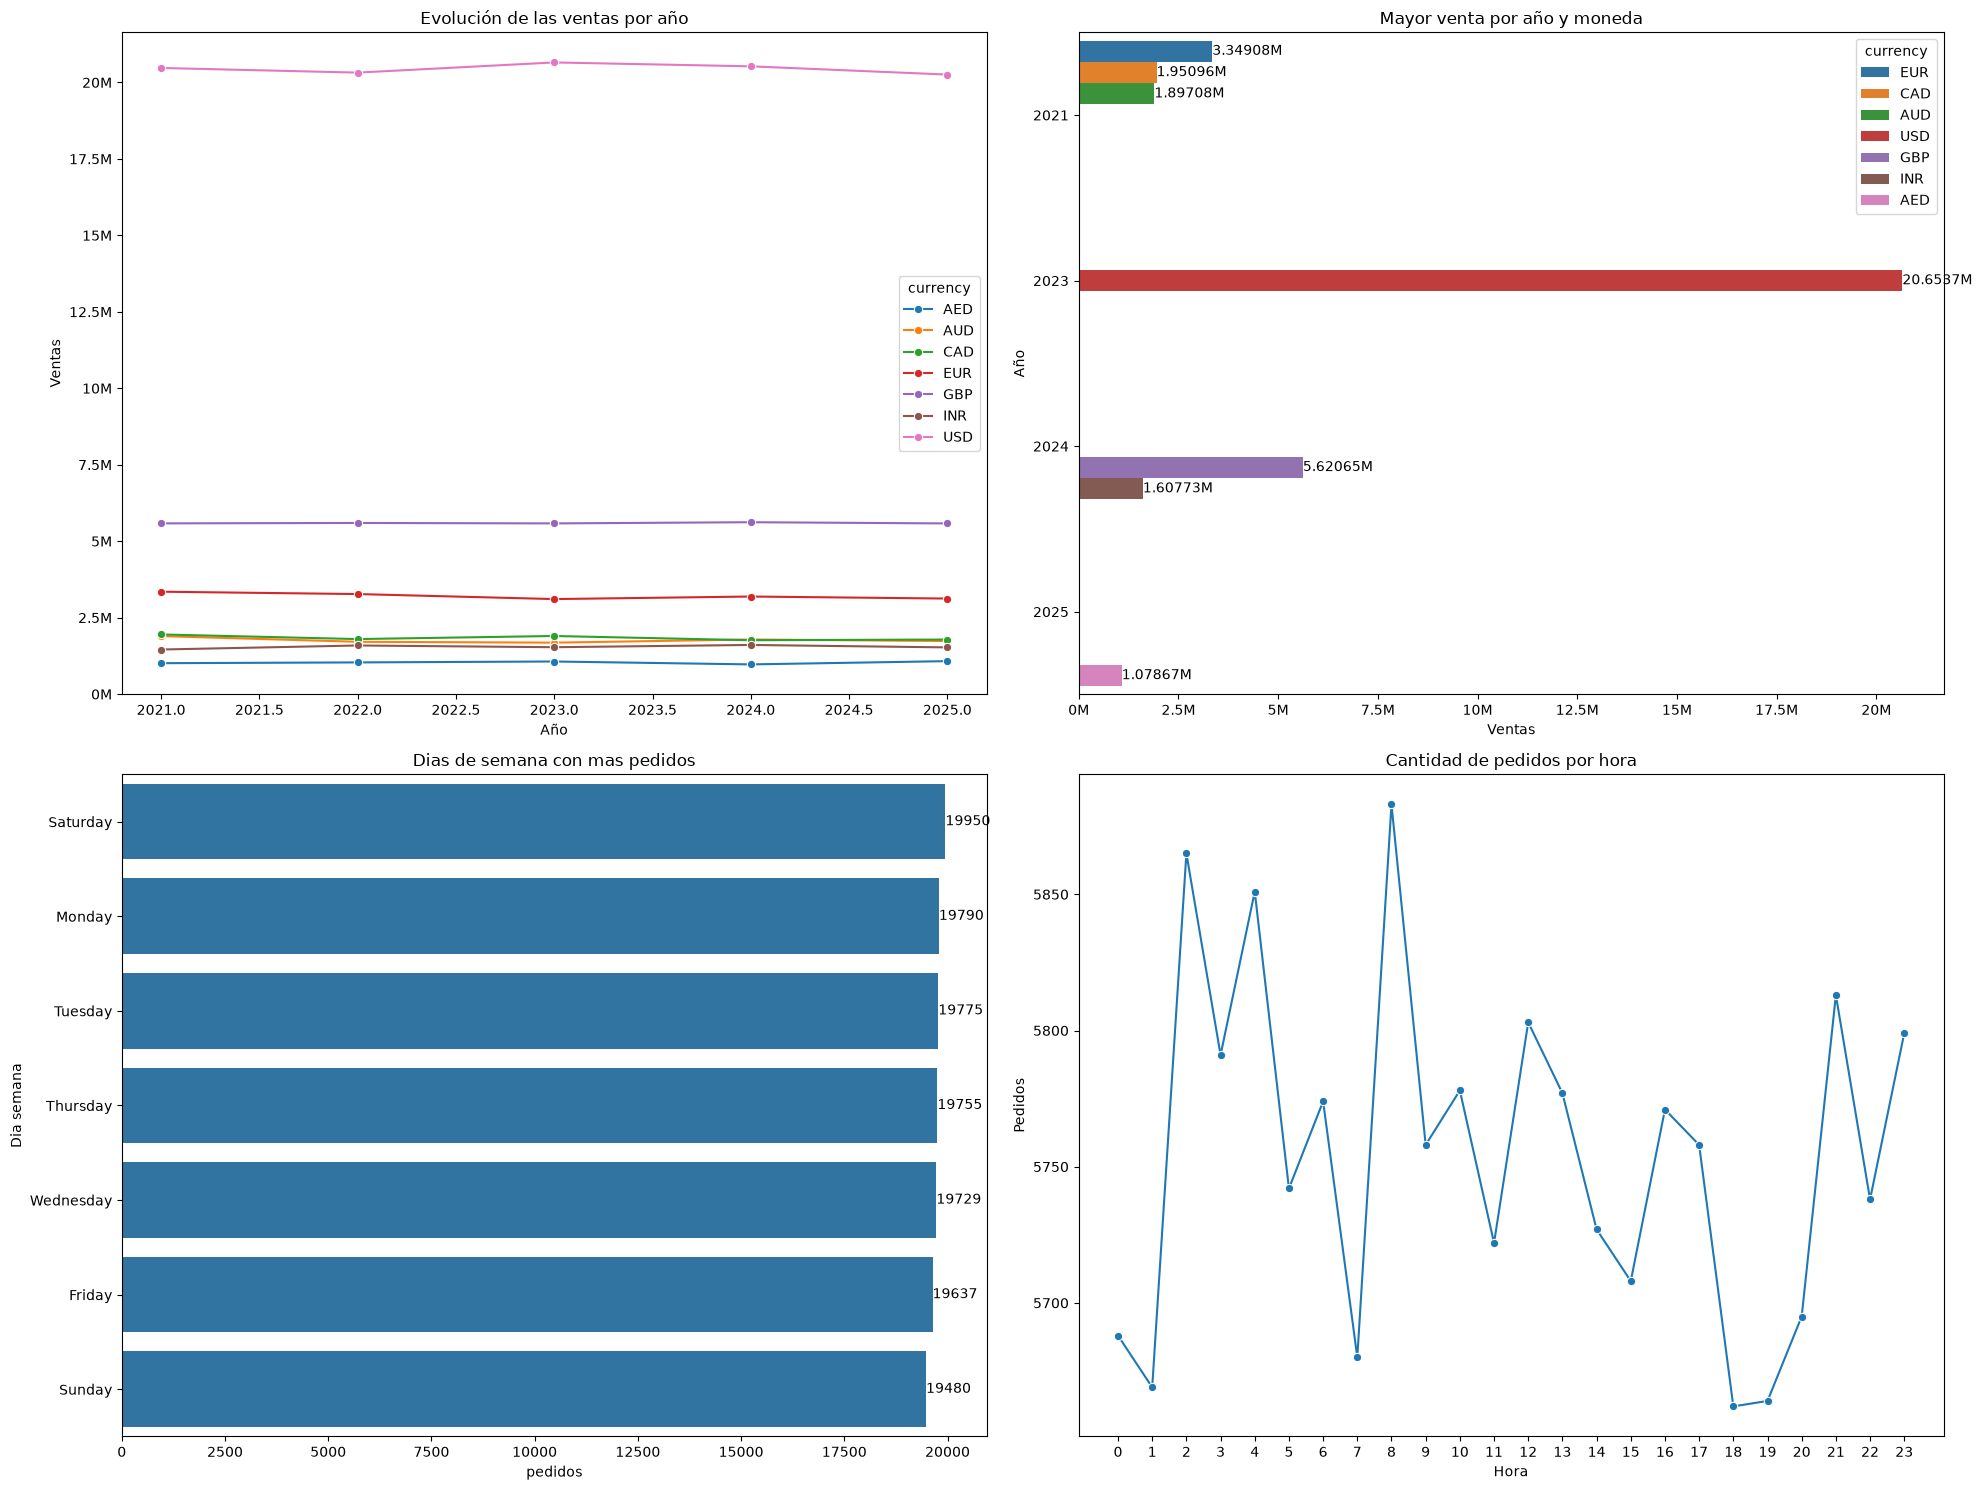

In [335]:
from matplotlib.ticker import FuncFormatter

def millones(x, pos):
    return f"{x / 1_000_000:g}M"

fig, axes = plt.subplots(2, 2, figsize=(20,15))

datos_grafico = evolucion_anual.reset_index()
#Grafico 1
sns.lineplot(
    data=datos_grafico,
    x="order_year",
    y="total_ventas",
    hue="currency",
    marker="o",
    ax=axes[0, 0]
)

axes[0,0].set_title("Evolución de las ventas por año")
axes[0,0].set_xlabel("Año")
axes[0,0].set_ylabel("Ventas")
axes[0,0].yaxis.set_major_formatter(FuncFormatter(millones))


datos_grafico2 = año_mayor_venta.reset_index()
#Grafico 2
sns.barplot(
    data=datos_grafico2,
    x="total_venta",
    y="order_year",
    hue="currency",
    width=0.9,
    orient="h",
    ax=axes[0,1]
)

axes[0,1].set_title("Mayor venta por año y moneda")
axes[0,1].set_xlabel("Ventas")
axes[0,1].set_ylabel("Año")
for container in axes[0,1].containers:
    axes[0,1].bar_label(
        container,
        labels=[f"{valor / 1_000_000:g}M" for valor in container.datavalues]
    )

axes[0,1].xaxis.set_major_formatter(FuncFormatter(millones))

#Grafico 3
sns.barplot(
    data = maxpedido_dia_semana,
    x = "total_pedidos",
    y = "order_weekday",
    ax = axes[1,0]
)

axes[1,0].set_title("Dias de semana con mas pedidos"),
axes[1,0].set_xlabel("pedidos"),
axes[1,0].set_ylabel("Dia semana")
for container in axes[1,0].containers:
    axes[1,0].bar_label(container)

#Grafico 4
datos_hora = max_pedido_hora.sort_index()

sns.lineplot(
    data=datos_hora,
    x="order_hour",
    y="total_pedidos",
    marker="o",
    ax=axes[1,1]
)

axes[1,1].set_title("Cantidad de pedidos por hora")
axes[1,1].set_xlabel("Hora")
axes[1,1].set_ylabel("Pedidos")

axes[1,1].set_xticks(range(24))

plt.tight_layout()
plt.show()

### 5. Envíos, devoluciones y satisfacción

>- ¿Existe alguna relación entre el método de envío y las devoluciones?

In [ ]:
relacion_envio_devolucion = (
    ecommerce
    .groupby(["shipping_method", "return_status"])
    .agg(
        total_pedidos=("order_id", "count")
    )
    .sort_index()
)

relacion_envio_devolucion

total_pedidos
shipping_method return_status                
Economy         No reembolsado          25911
                Returned                 1913
Express         No reembolsado          31990
                Returned                 2383
Same Day        No reembolsado          12995
                Returned                  918
Standard        No reembolsado          57758
                Returned                 4248

In [ ]:
relacion_envio_devolucion["porcentaje_devoluciones"] = (
    relacion_envio_devolucion["total_pedidos"]
    / relacion_envio_devolucion.groupby(level="shipping_method")["total_pedidos"].transform("sum")
    * 100
)

devoluciones_por_envio = (
    relacion_envio_devolucion
    .loc[(slice(None), "Returned"), :]
)

devoluciones_por_envio

,,total_pedidos,porcentaje_devoluciones
shipping_method,return_status,,
Economy,Returned,1913,6.875359
Express,Returned,2383,6.932767
Same Day,Returned,918,6.598146
Standard,Returned,4248,6.850950


Se comparó la tasa de devoluciones de cada método de envío respecto a su total de pedidos. Las tasas obtenidas son bastante similares, variando entre 6,60 % y 6,93 %.

Aunque Express presenta la mayor tasa de devolución y Same Day la menor, la diferencia entre ambos métodos es reducida. Por lo tanto, en los datos analizados no se observa una diferencia marcada en la tasa de devoluciones según el método de envío.

>- ¿Existen diferencias en la satisfacción de los clientes según el método de envío?

In [ ]:
relacion_satisfaccion_envio = (
    ecommerce
    .groupby(["shipping_method","review_sentiment"])
    .agg(total_reviews = ("customer_review","count"))
)


relacion_satisfaccion_envio["porcentaje_satisfaccion"] = (
    relacion_satisfaccion_envio["total_reviews"]
    / relacion_satisfaccion_envio.groupby(level="shipping_method")["total_reviews"].transform("sum")
    * 100
)

satisfaccion_por_envio = (
    relacion_satisfaccion_envio
    .loc[(slice(None)), :]
)

satisfaccion_por_envio

total_reviews  porcentaje_satisfaccion
shipping_method review_sentiment                                        
Economy         Negative                    162                 0.708816
                Neutral                    7094                31.039160
                Positive                  15599                68.252024
Express         Negative                    201                 0.709746
                Neutral                    8582                30.303672
                Positive                  19537                68.986582
Same Day        Negative                     70                 0.610820
                Neutral                    3481                30.375218
                Positive                   7909                69.013962
Standard        Negative                    359                 0.704972
                Neutral                   15527                30.490535
                Positive                  35038                68.804493

>- ¿Qué métodos de envío presentan mayor cantidad de devoluciones?

In [ ]:
devoluciones_por_envio.sort_values("total_pedidos",ascending = False)

,,total_pedidos,porcentaje_devoluciones
shipping_method,return_status,,
Standard,Returned,4248,6.850950
Express,Returned,2383,6.932767
Economy,Returned,1913,6.875359
Same Day,Returned,918,6.598146


En términos absolutos, el método **Standard** presenta la mayor cantidad de devoluciones, con 4.248 pedidos, seguido de **Express**, con 2.383. Sin embargo, estos métodos también concentran un mayor volumen de pedidos, por lo que una mayor cantidad de devoluciones no implica necesariamente una mayor proporción de devoluciones.

Al considerar la tasa de devolución, Express presenta el valor más alto con 6,93 %, mientras que las diferencias entre los métodos son reducidas.

>- ¿Qué métodos de envío presentan menores niveles de satisfacción?

In [ ]:
satisfaccionN_por_envio = (
    relacion_satisfaccion_envio
    .loc[(slice(None), "Negative"), :]
)

satisfaccionN_por_envio.sort_values("total_reviews",ascending=False)

,,total_reviews,porcentaje_satisfaccion
shipping_method,review_sentiment,,
Standard,Negative,359,0.704972
Express,Negative,201,0.709746
Economy,Negative,162,0.708816
Same Day,Negative,70,0.610820
